# Project S.A.F.E. Machine Learning Overview

Project S.A.F.E. is a dual-layer audio risk engine for identifying synthetic voice abuse, scam-style coercion, and harmless AI-generated audio. This notebook tells the story of the current machine learning pipeline from the spectrogram dataset through the trained classifier and its evaluation artifacts.

The flow is intentionally simple: load the data, inspect the features, reuse the repository's own preprocessing and model artifacts, then evaluate the current saved model on the same leakage-safe holdout split used during training.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import SETTINGS
PATHS = SETTINGS.paths
from train_model import _extract_image_features, _split_without_leakage

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

## Introduction

The current project is built around spectrogram images generated from source audio clips. The main supervised baseline uses those spectrograms to classify whether the source is human or synthetic. The repo also keeps semi-supervised and unsupervised variants, but the presentation below focuses on the latest supervised baseline because it is the strongest, most directly interpretable model in the saved artifacts.

Key design choices worth remembering:
- The split is leakage-safe at the `original_audio` group level.
- Augmented variants stay linked to the same source clip.
- The model consumes flattened 64x64 grayscale spectrograms, then reduces them with scaling plus PCA before classification.
- The latest saved evaluation report already contains the canonical confusion matrix and binary ranking metrics for this run.

## Data & Features Overview

The spectrogram manifest in `labels.csv` is the source of truth for the training set. Each row describes one generated spectrogram image and records how it was produced.

The most important fields are:
- `file_name`: the spectrogram image file.
- `file_path`: the on-disk image path used by the training script.
- `label`: the binary target, where `0` means human and `1` means synthetic.
- `category`: the human-readable class name.
- `source`: whether the image came from an original or augmented sample.
- `aug_type`: the augmentation method, when present.
- `original_audio`: the parent clip used to create the spectrogram family, which is the grouping key that prevents leakage across train and test splits.

In [2]:
labels = pd.read_csv(PATHS.labels_csv_path)
display(labels.head())

print(f'Total labeled spectrograms: {len(labels)}')
print('Label distribution:')
print(labels['label'].value_counts().sort_index())

feature_columns = ['file_name', 'file_path', 'label', 'category', 'source', 'aug_type', 'original_audio']
print('Available columns:')
print([column for column in feature_columns if column in labels.columns])

,file_name,file_path,label,category,source,aug_type,original_audio
0,hr10.m4a.png,spectrograms\human\hr10.m4a.png,0,human,original,none,hr10.m4a.mp3
1,hr10.m4a_noise.png,spectrograms\augmented\human\hr10.m4a_noise.png,0,human,augmented,noise,hr10.m4a.mp3
2,hr10.m4a_pitch_up.png,spectrograms\augmented\human\hr10.m4a_pitch_up...,0,human,augmented,pitch_up,hr10.m4a.mp3
3,hr10.m4a_pitch_down.png,spectrograms\augmented\human\hr10.m4a_pitch_do...,0,human,augmented,pitch_down,hr10.m4a.mp3
4,hr10.m4a_stretch.png,spectrograms\augmented\human\hr10.m4a_stretch.png,0,human,augmented,stretch,hr10.m4a.mp3


Total labeled spectrograms: 495
Label distribution:
label
0    280
1    215
Name: count, dtype: int64
Available columns:
['file_name', 'file_path', 'label', 'category', 'source', 'aug_type', 'original_audio']


## Model Architecture

The active baseline follows a compact but effective pipeline:
1. Load the spectrogram PNG referenced by `file_path`.
2. Convert it to a 64x64 grayscale image and flatten it into a 4,096-dimensional feature vector.
3. Apply standard scaling and PCA to compress the representation to 40 dimensions.
4. Feed the reduced features into the saved RandomForest classifier.

This notebook imports the same repository helpers used by training for the group-safe split and image feature extraction. That keeps the presentation aligned with the actual production path instead of a reimplementation.

In [4]:
report = json.loads(PATHS.training_report_path.read_text(encoding='utf-8'))
supervised_report = report['metrics']['supervised']

train_df, test_df, split_info = _split_without_leakage(
    labels,
    test_size=SETTINGS.training.test_split_ratio,
    random_state=SETTINGS.general.random_seed,
)

print('Leakage-safe split summary:')
print(split_info)
print()
print(f'Train rows: {len(train_df)}')
print(f'Test rows: {len(test_df)}')

train_paths = train_df['file_path'].map(lambda value: str((PROJECT_ROOT / Path(str(value))).resolve()))
test_paths = test_df['file_path'].map(lambda value: str((PROJECT_ROOT / Path(str(value))).resolve()))
X_train = _extract_image_features(train_paths.to_numpy(), SETTINGS.audio.feature_image_size)
X_test = _extract_image_features(test_paths.to_numpy(), SETTINGS.audio.feature_image_size)
y_train = train_df['label'].to_numpy()
y_test = test_df['label'].to_numpy()

feature_pipeline = joblib.load(PATHS.feature_pipeline_path)
model = joblib.load(PATHS.supervised_model_path)

X_test_scaled = feature_pipeline['scaler'].transform(X_test)
X_test_reduced = feature_pipeline['pca'].transform(X_test_scaled)
predictions = model.predict(X_test_reduced)
probabilities = model.predict_proba(X_test_reduced)
positive_index = list(model.classes_).index(1)
positive_probs = probabilities[:, positive_index]

evaluation_frame = test_df[['file_name', 'category', 'source', 'aug_type', 'original_audio']].copy()
evaluation_frame['actual'] = y_test
evaluation_frame['predicted'] = predictions
evaluation_frame['positive_probability'] = positive_probs
display(evaluation_frame.head(10))

preview_metrics = pd.DataFrame([
    {
        'metric': 'accuracy',
        'value': accuracy_score(y_test, predictions),
    },
    {
        'metric': 'balanced_accuracy',
        'value': balanced_accuracy_score(y_test, predictions),
    },
    {
        'metric': 'roc_auc',
        'value': roc_auc_score(y_test, positive_probs),
    },
    {
        'metric': 'pr_auc',
        'value': average_precision_score(y_test, positive_probs),
    },
])
display(preview_metrics)

print('Saved report summary:')
print(json.dumps({
    'accuracy': supervised_report.get('accuracy'),
    'balanced_accuracy': supervised_report.get('balanced_accuracy'),
    'macro_f1': supervised_report.get('macro_f1'),
    'weighted_f1': supervised_report.get('weighted_f1'),
    'roc_auc': supervised_report.get('roc_auc'),
    'pr_auc': supervised_report.get('pr_auc'),
}, indent=2))

Leakage-safe split summary:
{'split_level': 'original_audio', 'strategy': 'group_stratified', 'group_count_total': 99, 'group_count_train': 59, 'group_count_test': 40, 'group_label_distribution_train': {'0': 33, '1': 26}, 'group_label_distribution_test': {'0': 23, '1': 17}}

Train rows: 295
Test rows: 200


h:\Projects_AI\project_safe_v1\envSafeVone\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.1.post1 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
h:\Projects_AI\project_safe_v1\envSafeVone\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.4.1.post1 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
h:\Projects_AI\project_safe_v1\envSafeVone\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from vers

,file_name,category,source,aug_type,original_audio,actual,predicted,positive_probability
5,hr4.m4a (1).png,human,original,none,hr4.m4a (1).mp3,0,0,0.060000
6,hr4.m4a (1)_noise.png,human,augmented,noise,hr4.m4a (1).mp3,0,0,0.142857
7,hr4.m4a (1)_pitch_up.png,human,augmented,pitch_up,hr4.m4a (1).mp3,0,0,0.040000
8,hr4.m4a (1)_pitch_down.png,human,augmented,pitch_down,hr4.m4a (1).mp3,0,0,0.108571
9,hr4.m4a (1)_stretch.png,human,augmented,stretch,hr4.m4a (1).mp3,0,0,0.031429
10,hr4.m4a.png,human,original,none,hr4.m4a.mp3,0,0,0.060000
11,hr4.m4a_noise.png,human,augmented,noise,hr4.m4a.mp3,0,0,0.142857
12,hr4.m4a_pitch_up.png,human,augmented,pitch_up,hr4.m4a.mp3,0,0,0.040000
13,hr4.m4a_pitch_down.png,human,augmented,pitch_down,hr4.m4a.mp3,0,0,0.108571
14,hr4.m4a_stretch.png,human,augmented,stretch,hr4.m4a.mp3,0,0,0.031429


,metric,value
0,accuracy,0.965000
1,balanced_accuracy,0.958824
2,roc_auc,0.998005
3,pr_auc,0.997440


Saved report summary:
{
  "accuracy": 0.96,
  "balanced_accuracy": 0.9529411764705882,
  "macro_f1": 0.958501919286233,
  "weighted_f1": 0.9596846145865754,
  "roc_auc": 0.9981585677749361,
  "pr_auc": 0.9975737574781777
}


## Results & Evaluation

The current supervised baseline is the strongest artifact in the repo. On the saved holdout evaluation, it separates the two classes cleanly and ranks positive samples with very high probability quality. The plots below show the confusion matrix plus the two standard binary ranking curves that matter most for this project: ROC and Precision-Recall.

The figures are generated directly from the held-out predictions produced by the saved model and feature pipeline, so they reflect the current artifact rather than a static screenshot.

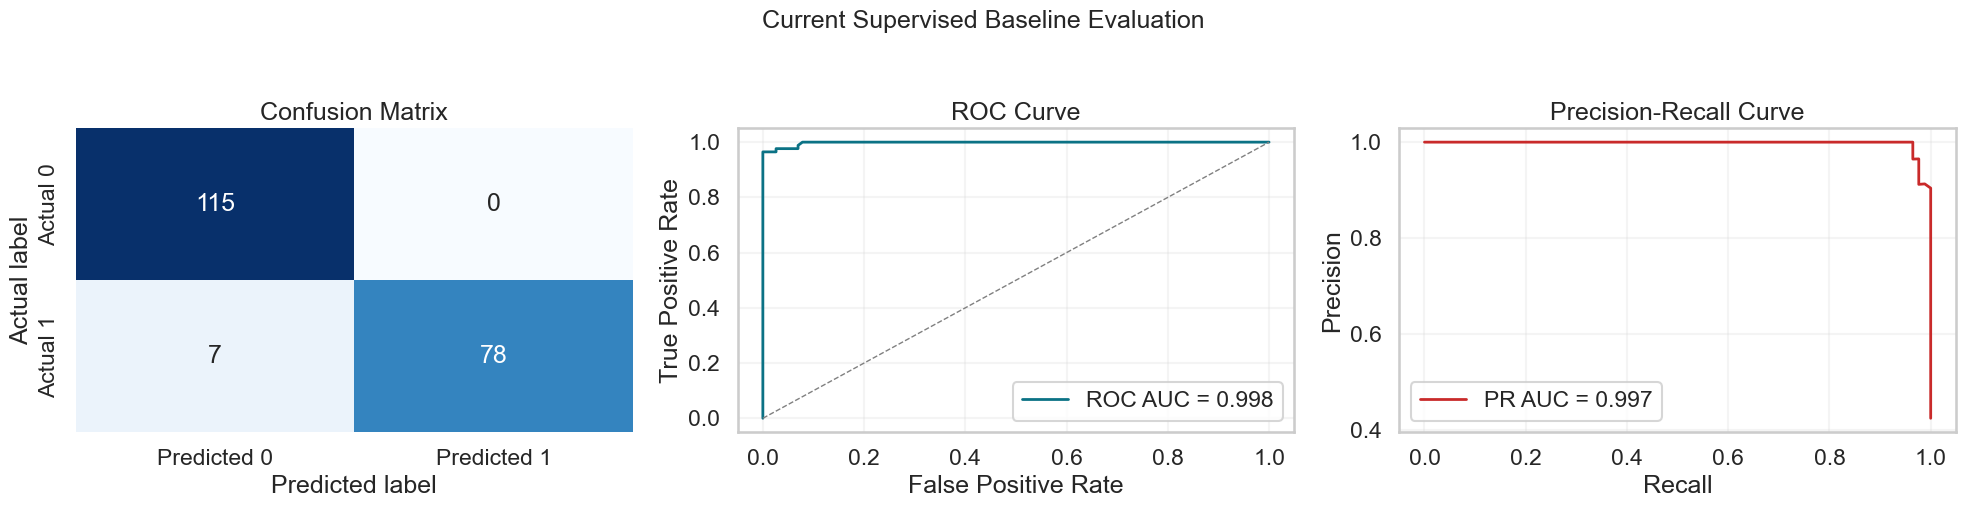

,metric,value
0,accuracy,0.965000
1,balanced_accuracy,0.958824
2,roc_auc,0.998005
3,pr_auc,0.997440


              precision    recall  f1-score   support

           0       0.94      1.00      0.97       115
           1       1.00      0.92      0.96        85

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



In [5]:
cm = confusion_matrix(y_test, predictions, labels=[0, 1])
roc_fpr, roc_tpr, _ = roc_curve(y_test, positive_probs)
precision, recall, _ = precision_recall_curve(y_test, positive_probs)
roc_auc = roc_auc_score(y_test, positive_probs)
pr_auc = average_precision_score(y_test, positive_probs)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm_frame = pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1'])
sns.heatmap(cm_frame, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('Actual label')

axes[1].plot(roc_fpr, roc_tpr, color='#0B7285', lw=2, label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

axes[2].plot(recall, precision, color='#C92A2A', lw=2, label=f'PR AUC = {pr_auc:.3f}')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')

for axis in axes:
    axis.grid(alpha=0.2)

fig.suptitle('Current Supervised Baseline Evaluation', y=1.03, fontsize=18)
fig.tight_layout()
plt.show()

summary_table = pd.DataFrame([
    {'metric': 'accuracy', 'value': accuracy_score(y_test, predictions)},
    {'metric': 'balanced_accuracy', 'value': balanced_accuracy_score(y_test, predictions)},
    {'metric': 'roc_auc', 'value': roc_auc},
    {'metric': 'pr_auc', 'value': pr_auc},
])
display(summary_table)

print(classification_report(y_test, predictions, zero_division=0))

## Closing Summary

The current ML stack already has a clear, defensible shape: a leakage-safe spectrogram dataset, a compact feature pipeline, and a high-performing supervised classifier with strong ranking metrics. The most useful next steps are operational rather than structural: keep tracking new audio families, expand the evaluation set, and compare the supervised baseline against the semi-supervised and unsupervised artifacts as the dataset grows.